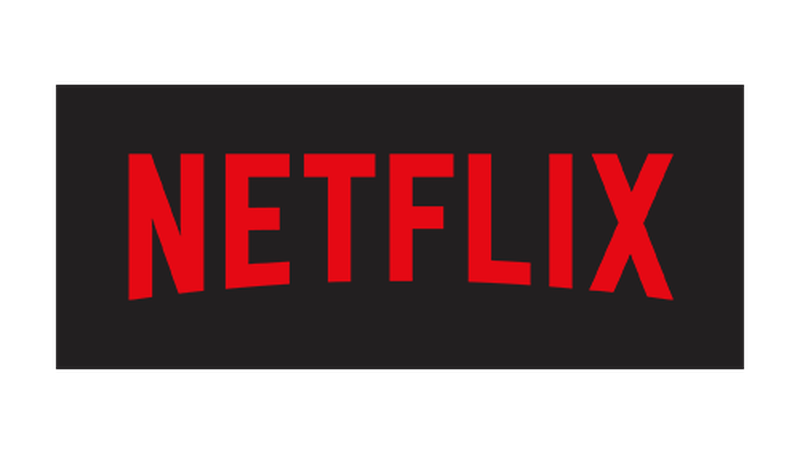

In [272]:
from IPython.display import Image, display
display(Image(filename="netflix_logo.png"))

# Netflix Data Science Project



## 1. Environment Setup and Data Loading
In this section, we import the necessary libraries for data manipulation (`pandas`, `numpy`) and visualization (`seaborn`, `matplotlib`). We also load the raw Netflix dataset.

In [273]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from warnings import filterwarnings
filterwarnings("ignore")



df = pd.read_csv("dataset/Netflix.csv")

## 2. Initial Data Inspection
Before cleaning, we take a quick look at the first few rows of the data, its dimensions, and the data types of each column to identify potential issues.

In [274]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [275]:
df.shape

(7787, 12)

In [276]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [277]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [278]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [279]:
df.duplicated().sum()

np.int64(0)

## 3. Data Cleaning
To ensure the quality of our analysis, we perform the following:
* **Drop Unnecessary Columns:** Removing `show_id` as it serves only as a unique identifier.
* **Impute Missing Values:** Filling gaps in `director`, `cast`, and `country` with "Unknown", and using the mode for `rating` and `date_added`.

In [280]:
df.drop(columns=['show_id'], inplace=True)

In [281]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)

## 4. Feature Engineering
We create new features to extract more value from the existing data:
1. **Date Extraction:** Converting `date_added` to datetime objects to extract year and month.
2. **Complexity Metrics:** Calculating the number of cast members and genres per title.
3. **Categorization:** Simplifying the content ratings into broader categories: **Adult**, **Teen**, and **Kids**.
4. **Localization:** Extracting the primary country of origin from the `country` column.

In [282]:
df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [283]:
df.drop(columns=['date_added'], inplace=True)

In [284]:
df['cast_count'] = df['cast'].apply(lambda x: len(x.split(',')))
df['genre_count'] = df['genres'].apply(lambda x: len(x.split(',')))

In [285]:
df['duration_type'] = df['type']

df.rename(columns={'duration':'duration_value'}, inplace=True)

In [286]:
df['country_main'] = df['country'].apply(lambda x: x.split(',')[0])

In [287]:
def simplify_rating(r):
    if r in ['TV-MA','R','NC-17']:
        return "Adult"
    elif r in ['PG-13','TV-14']:
        return "Teen"
    else:
        return "Kids"

df['rating_category'] = df['rating'].apply(simplify_rating)

In [288]:
df.drop(columns=['rating'], inplace=True)

## 5. Exploratory Data Analysis & Visualization
With the data cleaned and enriched, we now move to the visualization phase. This help us identify:
* The distribution of content types (Movies vs. TV Shows).
* Trends in content releases over the years.
* Relationship between content duration and its category.

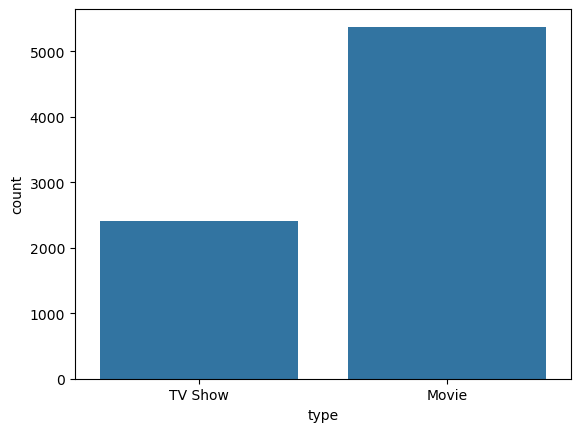

In [289]:
sns.countplot(x="type",data=df)
plt.show()

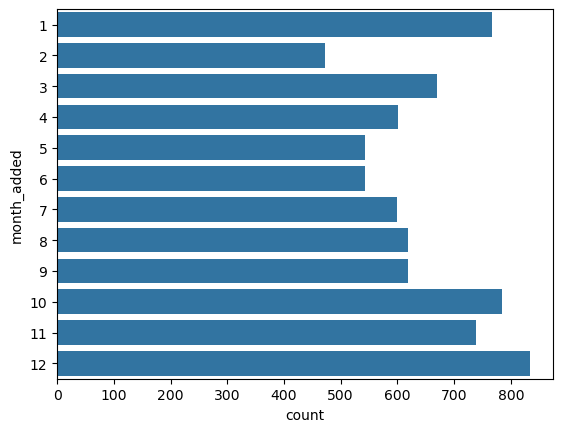

In [290]:
sns.countplot(y="month_added",data=df)
plt.show()

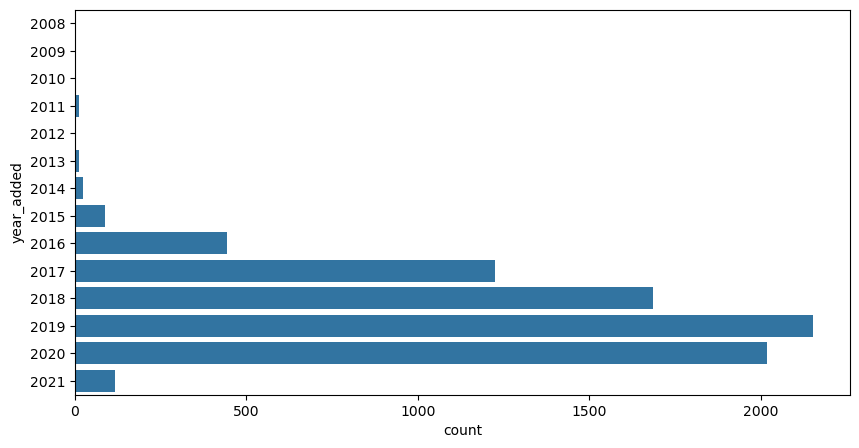

In [291]:
plt.figure(figsize=(10,5))
sns.countplot(y=df["year_added"])
plt.show()

In [292]:
df['has_director'] = df['director'].apply(lambda x: 0 if x=='Unknown' else 1)

In [293]:
df.corr(numeric_only=True)

,release_year,duration_value,year_added,month_added,cast_count,genre_count,has_director
release_year,1.000000,-0.240836,0.100115,-0.009661,-0.086585,-0.052931,-0.166603
duration_value,-0.240836,1.000000,0.037102,-0.024913,0.096601,0.092256,0.820335
year_added,0.100115,0.037102,1.000000,-0.135006,0.113470,0.060552,-0.001745
month_added,-0.009661,-0.024913,-0.135006,1.000000,0.001902,-0.002332,-0.028360
cast_count,-0.086585,0.096601,0.113470,0.001902,1.000000,0.219182,0.008707
genre_count,-0.052931,0.092256,0.060552,-0.002332,0.219182,1.000000,-0.041000
has_director,-0.166603,0.820335,-0.001745,-0.028360,0.008707,-0.041000,1.000000


<Axes: >

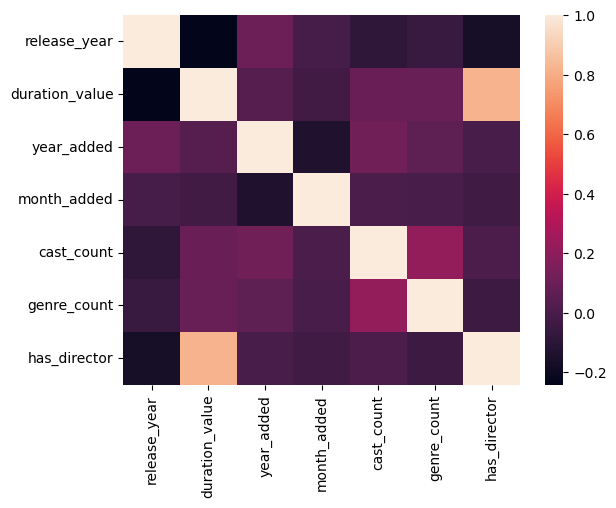

In [294]:
sns.heatmap(df.corr(numeric_only=True))

## Q1] Develop a Content-Type labeling system:

In [295]:
df.head()

,type,title,director,cast,country,release_year,duration_value,genres,description,year_added,month_added,cast_count,genre_count,duration_type,country_main,rating_category,has_director
0,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,11,3,TV Show,Brazil,Adult,0
1,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2008,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017,12,8,3,Movie,India,Adult,1
2,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2016,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019,1,4,3,Movie,Indonesia,Kids,1
3,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016,3,11,1,Movie,United States,Adult,1
4,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2017,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018,12,1,3,TV Show,United Kingdom,Kids,0


### LOGISTIC - REGRESSION:

In [296]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle


num_features = ['cast_count', 'genre_count', 'duration_value']

cat_features = ['country_main', 'rating_category']

X = df[num_features + cat_features]
y = df['type']

# Split the data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])



pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

from sklearn.model_selection import train_test_split, GridSearchCV
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the pipeline model (similar to laptop project)
with open('netflix_type_predictor_logisticRegression_pipeline.pkl', 'wb') as f:
    pickle.dump(best_model, f)


# Example prediction function (like app.py in laptop project)
def predict_content_type(cast_count, genre_count, duration_value,
                         country_main, rating_category):
    # Create input DataFrame
    query_df = pd.DataFrame({
        'cast_count': [cast_count],
        'genre_count': [genre_count],
        'duration_value': [duration_value],
        'country_main': [country_main],
        'rating_category': [rating_category]
    })
    
    # Load the pipeline
    with open('netflix_type_predictor_logisticRegression_pipeline.pkl', 'rb') as f:
        pipe = pickle.load(f)
    
    # Predict
    prediction = pipe.predict(query_df)[0]
    content_type = 'TV Show' if prediction == 1 else 'Movie'
    probability = pipe.predict_proba(query_df)[0]
    conf_movie = probability[0] * 100
    conf_tv = probability[1] * 100
    
    return f"Predicted Type: {content_type} (Confidence: {max(conf_movie, conf_tv):.2f}%)"

# Example usage
print("\nExample Prediction:")
result = predict_content_type(cast_count=8, genre_count=3, duration_value=143,
    country_main='India', rating_category='Adult'
)
print(result)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Accuracy: 0.9987

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1076
     TV Show       1.00      1.00      1.00       482

    accuracy                           1.00      1558
   macro avg       1.00      1.00      1.00      1558
weighted avg       1.00      1.00      1.00      1558


Confusion Matrix:
[[1074    2]
 [   0  482]]

Example Prediction:
Predicted Type: Movie (Confidence: 100.00%)


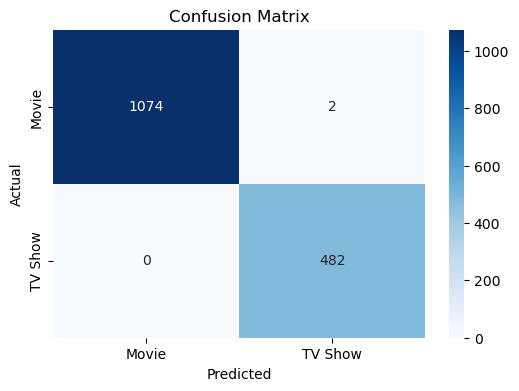

In [297]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Movie', 'TV Show'],
            yticklabels=['Movie', 'TV Show'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### NAIVE - BAYES (Bernoulli) :

In [298]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV

# Pipeline
pipeline_nb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BernoulliNB())
])

# 🔥 Hyperparameter tuning for Naive Bayes
param_grid_nb = {
    'classifier__alpha': [0.1, 0.5, 1.0, 2.0],
    'classifier__binarize': [0.0, 0.5, 1.0],
    'classifier__fit_prior': [True, False]
}

grid_nb = GridSearchCV(
    pipeline_nb,
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train
grid_nb.fit(X_train, y_train)

# Best model
best_nb_model = grid_nb.best_estimator_

print("Best Parameters (Naive Bayes):", grid_nb.best_params_)

# Predictions
y_pred = best_nb_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTuned Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save tuned model
with open('netflix_type_predictor_naiveBayes_tuned.pkl', 'wb') as f:
    pickle.dump(best_nb_model, f)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters (Naive Bayes): {'classifier__alpha': 2.0, 'classifier__binarize': 0.0, 'classifier__fit_prior': False}

Tuned Accuracy: 0.9050

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      0.86      0.93      1076
     TV Show       0.77      1.00      0.87       482

    accuracy                           0.91      1558
   macro avg       0.88      0.93      0.90      1558
weighted avg       0.93      0.91      0.91      1558


Confusion Matrix:
[[928 148]
 [  0 482]]


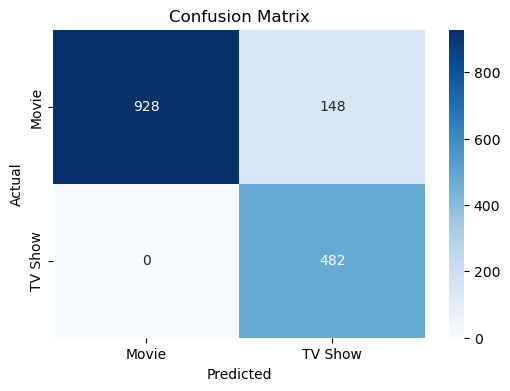

In [299]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Movie', 'TV Show'],
            yticklabels=['Movie', 'TV Show'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### KNN:

In [300]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Pipeline
pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# 🔥 Hyperparameter tuning
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan'],
    'classifier__p': [1, 2]  # 1=manhattan, 2=euclidean
}

grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train
grid_knn.fit(X_train, y_train)

# Best model
best_knn_model = grid_knn.best_estimator_

print("Best Parameters (KNN):", grid_knn.best_params_)

# Predictions
y_pred = best_knn_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTuned Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save tuned model
with open('netflix_type_predictor_knn_tuned.pkl', 'wb') as f:
    pickle.dump(best_knn_model, f)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters (KNN): {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'distance'}

Tuned Accuracy: 0.9917

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      0.99      0.99      1076
     TV Show       0.98      1.00      0.99       482

    accuracy                           0.99      1558
   macro avg       0.99      0.99      0.99      1558
weighted avg       0.99      0.99      0.99      1558


Confusion Matrix:
[[1065   11]
 [   2  480]]


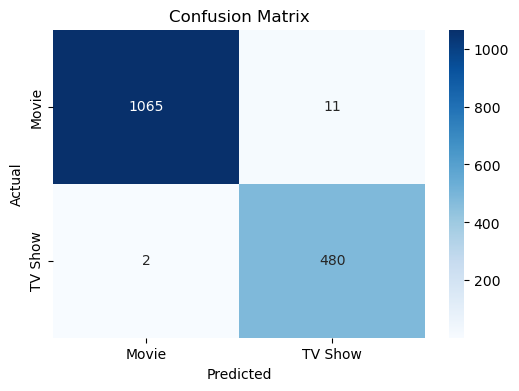

In [301]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Movie', 'TV Show'],
            yticklabels=['Movie', 'TV Show'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **CONCLUSION:** Highest accuracy is acheived through Logistic Regression.

## Q2] Predict whether a piece of content is a Movie or a TV Show based on features like cast-size, country, and release trends?

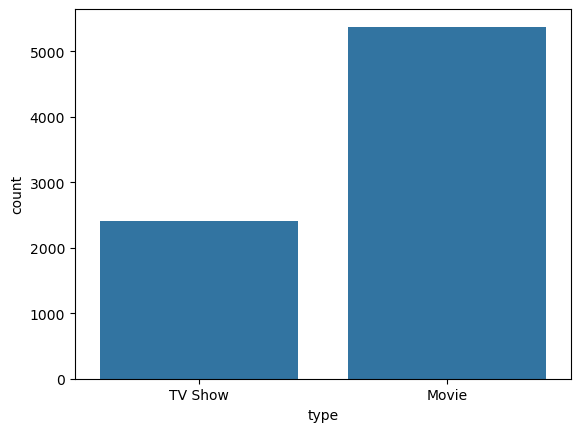

In [302]:
sns.countplot(x=df["type"])
plt.show()

In [303]:
data = df.groupby("type")["genre_count"].sum().reset_index()
data

,type,genre_count
0,Movie,11546
1,TV Show,5525


In [304]:
data = df.groupby("type")["cast_count"].sum().reset_index()
data

,type,cast_count
0,Movie,38738
1,TV Show,17935


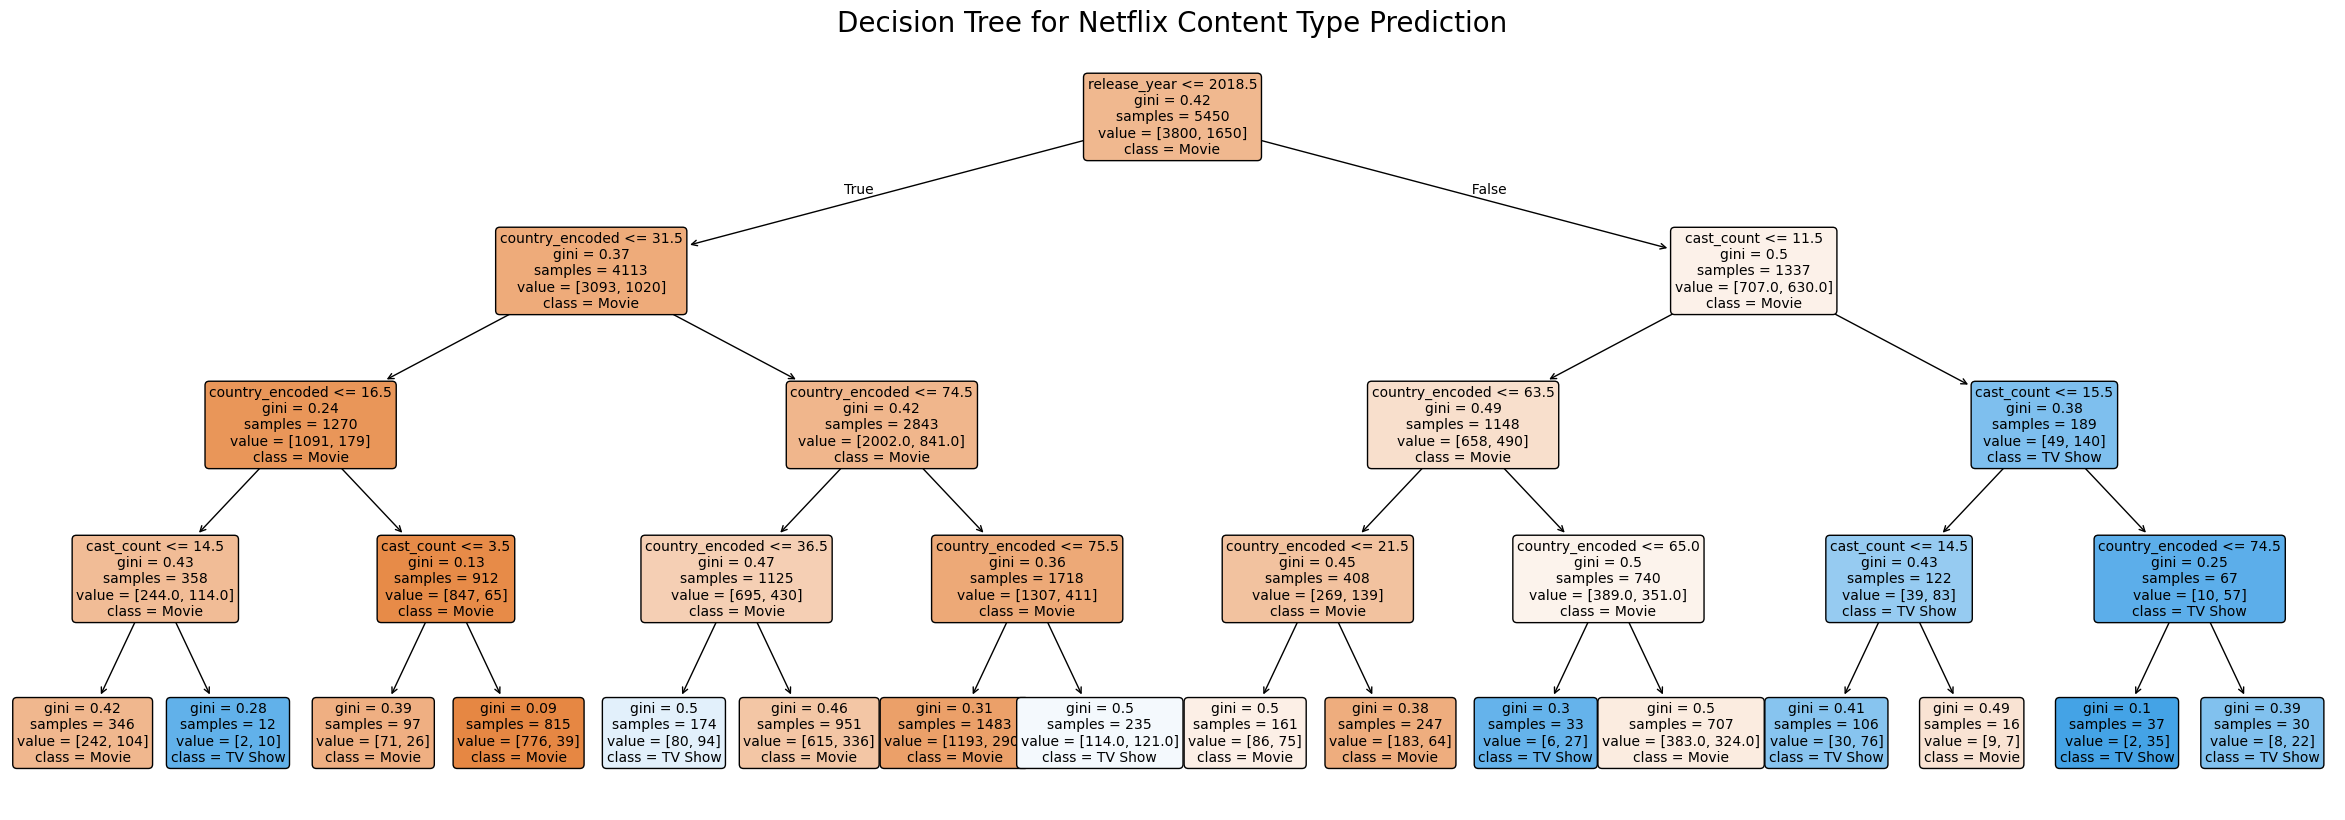

Accuracy: 0.7064612751390672


In [305]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1. Preprocessing categorical features
# We extract the first country and first genre to simplify the categories
df['first_country'] = df['country'].fillna('Unknown').apply (lambda x: x.split(',')[0])

# 2. Encode strings to numbers
le_country = LabelEncoder()

df['country_encoded'] = le_country.fit_transform(df['first_country'])



feature_cols = ["cast_count", "country_encoded", "release_year"]
X = df[feature_cols]
y = df["type"]


X_train , X_test , y_train, y_test = train_test_split(X,y, test_size=0.3,random_state=42)


model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train , y_train)


plt.figure(figsize=(30,10))
plot_tree(model, 
          feature_names=feature_cols, 
          class_names=["Movie", "TV Show"], 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          precision=2)

plt.title("Decision Tree for Netflix Content Type Prediction", fontsize=20)
plt.show()


print("Accuracy:",model.score(X_test, y_test))

## 🌳 Decision Tree for Netflix Content Type Prediction

The decision tree model was trained to classify Netflix content into **Movies** and **TV Shows** using features such as:
- `release_year`
- `country_encoded`
- `cast_count`

### 🔎 Model Insights
- The tree splits primarily on **release year**, showing that newer releases tend to follow different classification patterns than older ones.  
- **Country encoding** and **cast count** act as secondary features, refining predictions when year alone is insufficient.  
- Leaf nodes reveal the final classification outcome, with color-coding distinguishing between predicted classes.

### 📈 Performance
- **Accuracy:** ~0.706 (≈71%)  
- This indicates the model correctly classifies about 7 out of 10 titles.  
- While interpretable and easy to visualize, the decision tree may suffer from **overfitting** and limited generalization compared to ensemble methods.

### ✅ Key Takeaway
The decision tree provides a transparent view of how Netflix content is classified, highlighting the importance of **release year** as the dominant feature. However, for higher accuracy and robustness, ensemble approaches (e.g., Random Forests, Gradient Boosting) would likely outperform this single-tree model.

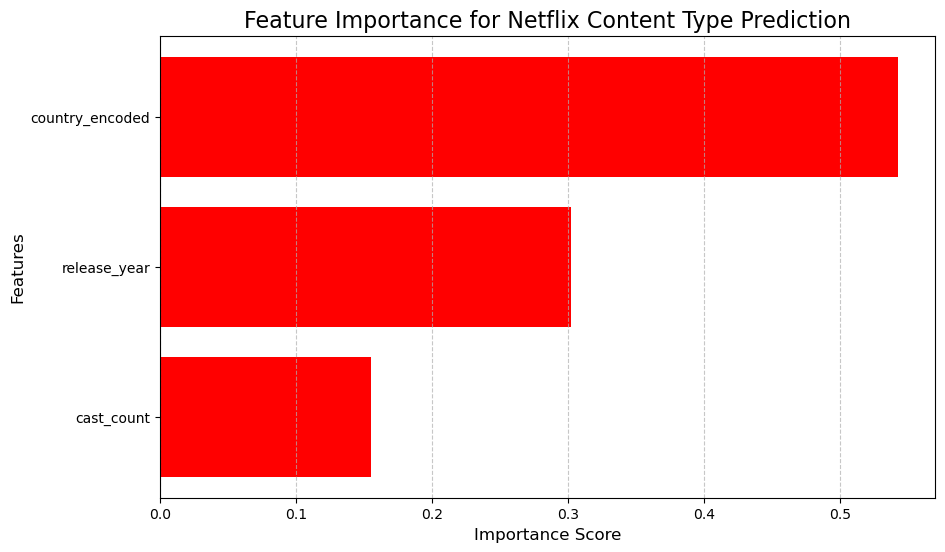

,index,Feature,Importance
0,0,country_encoded,0.542345
1,1,release_year,0.302328
2,2,cast_count,0.155326


In [306]:


# 1. Create a DataFrame to hold the feature names and their corresponding importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)

# 2. Plot the Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='red')

plt.title('Feature Importance for Netflix Content Type Prediction', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

# 3. Print the values for reference
# Create the sorted dataframe and drop the old index
importance_display = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the clean table
importance_display.reset_index()

## Q3] Which countries dominate Netflix content, and how does the Movie vs TV-Show ratio change across the top 10 countries?

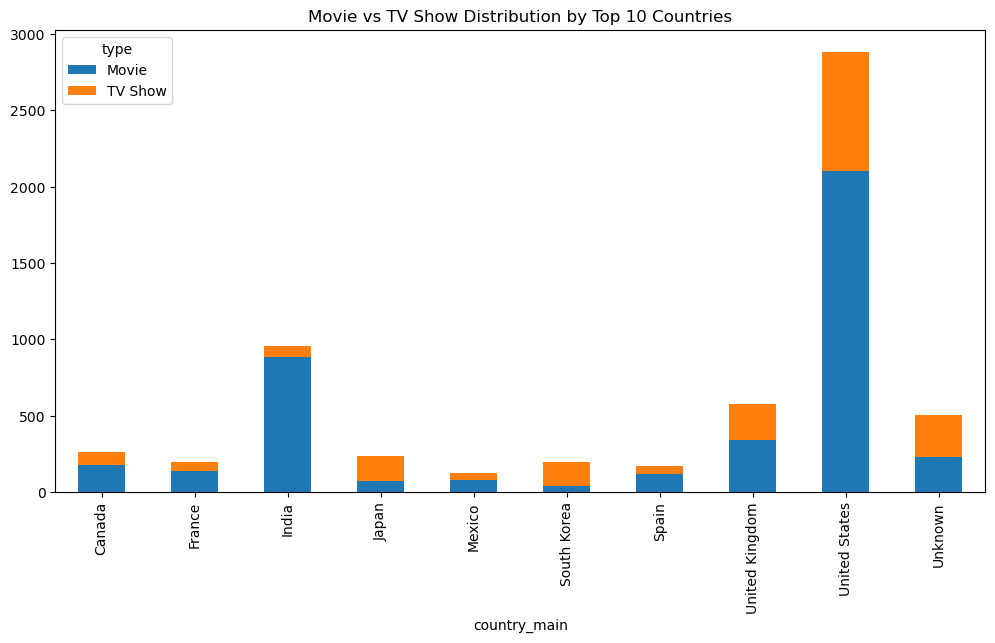

In [307]:
top10_countries = df['country_main'].value_counts().head(10).index
country_type = df[df['country_main'].isin(top10_countries)].groupby(['country_main', 'type']).size().unstack()
country_type.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Movie vs TV Show Distribution by Top 10 Countries')
plt.show()

## Q4] Do titles with a known director have significantly higher cast_count, genre_count, or longer duration than “Unknown” director titles?

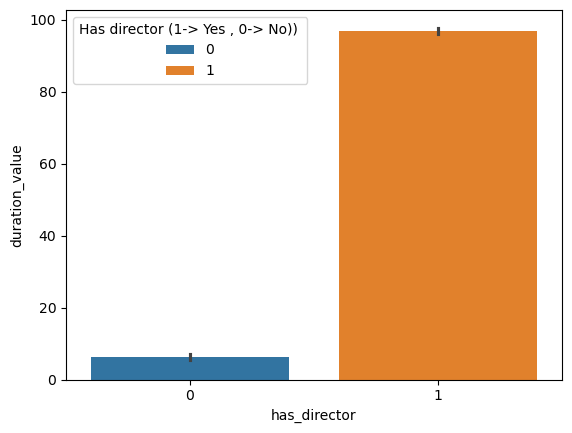

In [308]:
df.groupby('has_director')[['cast_count', 'genre_count', 'duration_value']].mean().round(2)
sns.barplot(x='has_director', y='duration_value',hue="has_director", data=df)
plt.legend(title="Has director (1-> Yes , 0-> No)) ")
plt.show()

In [309]:
df.head()

,type,title,director,cast,country,release_year,duration_value,genres,description,year_added,month_added,cast_count,genre_count,duration_type,country_main,rating_category,has_director,first_country,country_encoded
0,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,11,3,TV Show,Brazil,Adult,0,Brazil,6
1,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2008,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017,12,8,3,Movie,India,Adult,1,India,28
2,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2016,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019,1,4,3,Movie,Indonesia,Kids,1,Indonesia,29
3,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016,3,11,1,Movie,United States,Adult,1,United States,75
4,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2017,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018,12,1,3,TV Show,United Kingdom,Kids,0,United Kingdom,74


## Q5] Develop a Content- recommendation system:

In [310]:
import pandas as pd
import pickle
import numpy as np
from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# STEP 1: Create tags (same as before)
# -----------------------------
df['tags'] = (
    df['title'].fillna('') + " " +
    df['genres'].fillna('') + " " +
    df['description'].fillna('') + " " +
    df['cast'].fillna('') + " " +
    df['director'].fillna('') + " " +
    df['country_main'].fillna('') + " " +
    df['rating_category'].fillna('') + " " +
    df['type'].fillna('')
)

df['tags'] = df['tags'].str.lower()

# -----------------------------
# STEP 2: Tokenization
# -----------------------------
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tags'].apply(
    lambda x: [word for word in word_tokenize(x) 
               if word.isalnum() and word not in stop_words]
)


# -----------------------------
# STEP 3: Train Word2Vec Model
# -----------------------------
w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

# -----------------------------
# STEP 4: Convert each content into vector
# -----------------------------
def get_doc_vector(tokens):
    vectors = []
    for word in tokens:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])
    
    if len(vectors) == 0:
        return np.zeros(100)
    
    return np.mean(vectors, axis=0)

df['vector'] = df['tokens'].apply(get_doc_vector)

# Convert to matrix
vectors = np.vstack(df['vector'].values)

# -----------------------------
# STEP 5: Recommendation Class
# -----------------------------
class RecommendationModel:
    def __init__(self, vectors, df, w2v_model):
        self.vectors = vectors
        self.df = df.reset_index(drop=True)
        self.w2v_model = w2v_model

    def text_to_vector(self, text):
        tokens = word_tokenize(text.lower())
        return get_doc_vector(tokens)

    def recommend(self, content, top_n=10):
        mask = self.df['title'].str.contains(content, case=False, na=False)
        
        if mask.any():
            idx = self.df[mask].index[0]
            query_vec = self.vectors[idx].reshape(1, -1)
            print(" Found exact title → using full features")
        else:
            query_vec = self.text_to_vector(content).reshape(1, -1)

        similarity = cosine_similarity(query_vec, self.vectors)[0]

        content_list = sorted(
            list(enumerate(similarity)),
            reverse=True,
            key=lambda x: x[1]
        )[1:top_n+1]

        print(f"\n\nRecommendations similar to: **{content}**\n")

        for rank, (i, score) in enumerate(content_list, 1):
            row = self.df.iloc[i]
            print(f"{rank:2}) • {row['title']}  "
                  f"| {row['type']}  "
                  f"| {row['genres'][:70]}...")

# -----------------------------
# STEP 6: Save & Load Model
# -----------------------------
model = RecommendationModel(vectors, df, w2v_model)

with open("content_recommendation_word2vec.pkl", "wb") as f:
    pickle.dump(model, f)

with open("content_recommendation_word2vec.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# -----------------------------
# STEP 7: Test
# -----------------------------
loaded_model.recommend("Kesari 2")
loaded_model.recommend("Dune")
loaded_model.recommend("Stranger Things")
loaded_model.recommend("Article 15")
loaded_model.recommend("Raone")
loaded_model.recommend("3 Idiots")
loaded_model.recommend("Dhurandhar")
loaded_model.recommend("Dhurandhar - The Revenge")



Recommendations similar to: **Kesari 2**

 1) • Mukhsin  | Movie  | Children & Family Movies, Comedies, Dramas...
 2) • The Rainbow Troops  | Movie  | Children & Family Movies, Dramas, International Movies...
 3) • Magnus  | Movie  | Children & Family Movies, Documentaries, International Movies...
 4) • Misfit 2  | Movie  | Children & Family Movies, Comedies, International Movies...
 5) • The Breadwinner  | Movie  | Children & Family Movies, Dramas, International Movies...
 6) • Luccas Neto in: Children's Day  | Movie  | Children & Family Movies, Comedies, Music & Musicals...
 7) • Yes or No  | Movie  | International Movies, LGBTQ Movies, Romantic Movies...
 8) • Garuda in My Heart 2  | Movie  | Children & Family Movies, Dramas, Sports Movies...
 9) • Nang Nak  | Movie  | Horror Movies, International Movies, Romantic Movies...
10) • Yes or No 2.5  | Movie  | International Movies, LGBTQ Movies, Romantic Movies...


Recommendations similar to: **Dune**

 1) • 1920  | Movie  | Horror Mo

### Q6] Can we forecast how many titles Netflix will add in 2022–2025?

In [311]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

yearly_data = df.groupby(['year_added','genre_count']).size().reset_index(name='title_count')
yearly_data = yearly_data[yearly_data['year_added'] <= 2021]

X = yearly_data[['year_added','genre_count']]
y = yearly_data['title_count']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

future_years = pd.DataFrame({
    'year_added': [2022, 2023, 2024, 2025],
    'genre_count': [yearly_data['genre_count'].mean()] * 4
})

### a) Linear Regression:

In [312]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=1)),
    ('model', LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)
linear_forecast = linear_pipeline.predict(future_years)

### b) Adaboost:

In [313]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

ada_pipeline = Pipeline([
    ('model', AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=3),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ))
])

ada_pipeline.fit(X_train, y_train)

y_pred_ada = ada_pipeline.predict(X_test)
ada_forecast = ada_pipeline.predict(future_years)

### c) Decision tree:

In [314]:
from sklearn.tree import DecisionTreeRegressor

tree_pipeline = Pipeline([
    ('model', DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    ))
])

tree_pipeline.fit(X_train, y_train)

y_pred_tree = tree_pipeline.predict(X_test)
tree_forecast = tree_pipeline.predict(future_years)

### d) Extratrees:

In [315]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error


et_pipeline = Pipeline([
    ('model', ExtraTreesRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ))
])

et_pipeline.fit(X_train, y_train)

y_pred_et = et_pipeline.predict(X_test)
et_forecast = et_pipeline.predict(future_years)


### e) Support Vector Regression (SVR):

In [316]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf'))
])

svr_pipeline.fit(X_train, y_train)
y_pred_svr = svr_pipeline.predict(X_test)
svr_forecast = svr_pipeline.predict(future_years)

### f) Gradient Boosting Regression:

In [317]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error


gb_pipeline = Pipeline([
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)
gb_forecast = gb_pipeline.predict(future_years)

In [318]:
forecast_df = pd.DataFrame({
    'Year': [2022, 2023, 2024, 2025],
    'Linear': linear_forecast.astype(int),
    'AdaBoost': ada_forecast.astype(int),
    'Decision Tree': tree_forecast.astype(int),
    'Extra Trees': et_forecast.astype(int),
    'Support-Vector Regression':svr_forecast.astype(int),
    'Gradient-Boosting Regression':gb_forecast.astype(int)
})

print(forecast_df)


print("\n\n\n")


tolerance=5

results = pd.DataFrame({
    'Model': ['Linear', 'AdaBoost', 'Decision Tree','Extra Trees','Support-Vector Regression','Gradient-Boosting Regression'],
    'R2 Score': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ada),
        r2_score(y_test, y_pred_tree),
        r2_score(y_test,y_pred_et),
        r2_score(y_test,y_pred_svr),
        r2_score(y_test,y_pred_gb)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_ada),
        mean_absolute_error(y_test, y_pred_tree),
        mean_absolute_error(y_test, y_pred_et),
        mean_absolute_error(y_test, y_pred_svr),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    "Accuracy in %":[
        (abs(y_test - y_pred_linear) <= tolerance).mean()*100,
        (abs(y_test - y_pred_ada) <= tolerance).mean()*100,
        (abs(y_test - y_pred_tree) <= tolerance).mean()*100,
        (abs(y_test - y_pred_et) <= tolerance).mean()*100,
        (abs(y_test - y_pred_svr) <= tolerance).mean()*100,
        (abs(y_test - y_pred_gb) <= tolerance).mean()*100,
        
    ]
})

print(results)

   Year  Linear  AdaBoost  Decision Tree  Extra Trees  \
0  2022     536        39             28          177   
1  2023     583        39             28          177   
2  2024     630        39             28          177   
3  2025     677        39             28          177   

   Support-Vector Regression  Gradient-Boosting Regression  
0                         28                            39  
1                         27                            39  
2                         26                            39  
3                         25                            39  




                          Model  R2 Score         MAE  Accuracy in %
0                        Linear  0.338272  175.998586            0.0
1                      AdaBoost  0.972426   29.357372           25.0
2                 Decision Tree  0.837528   64.009615           37.5
3                   Extra Trees  0.950903   44.308093           25.0
4     Support-Vector Regression -0.476629  208.337355       

### CONCLUSION] 
Tree-based models such as **DecisionTreeRegressor**, **ExtraTreesRegressor**, **AdaBoostRegressor**, and **GradientBoostingRegressor** achieved high accuracy on test data, with **Gradient Boosting** giving the best performance in terms of R² score and MAE.


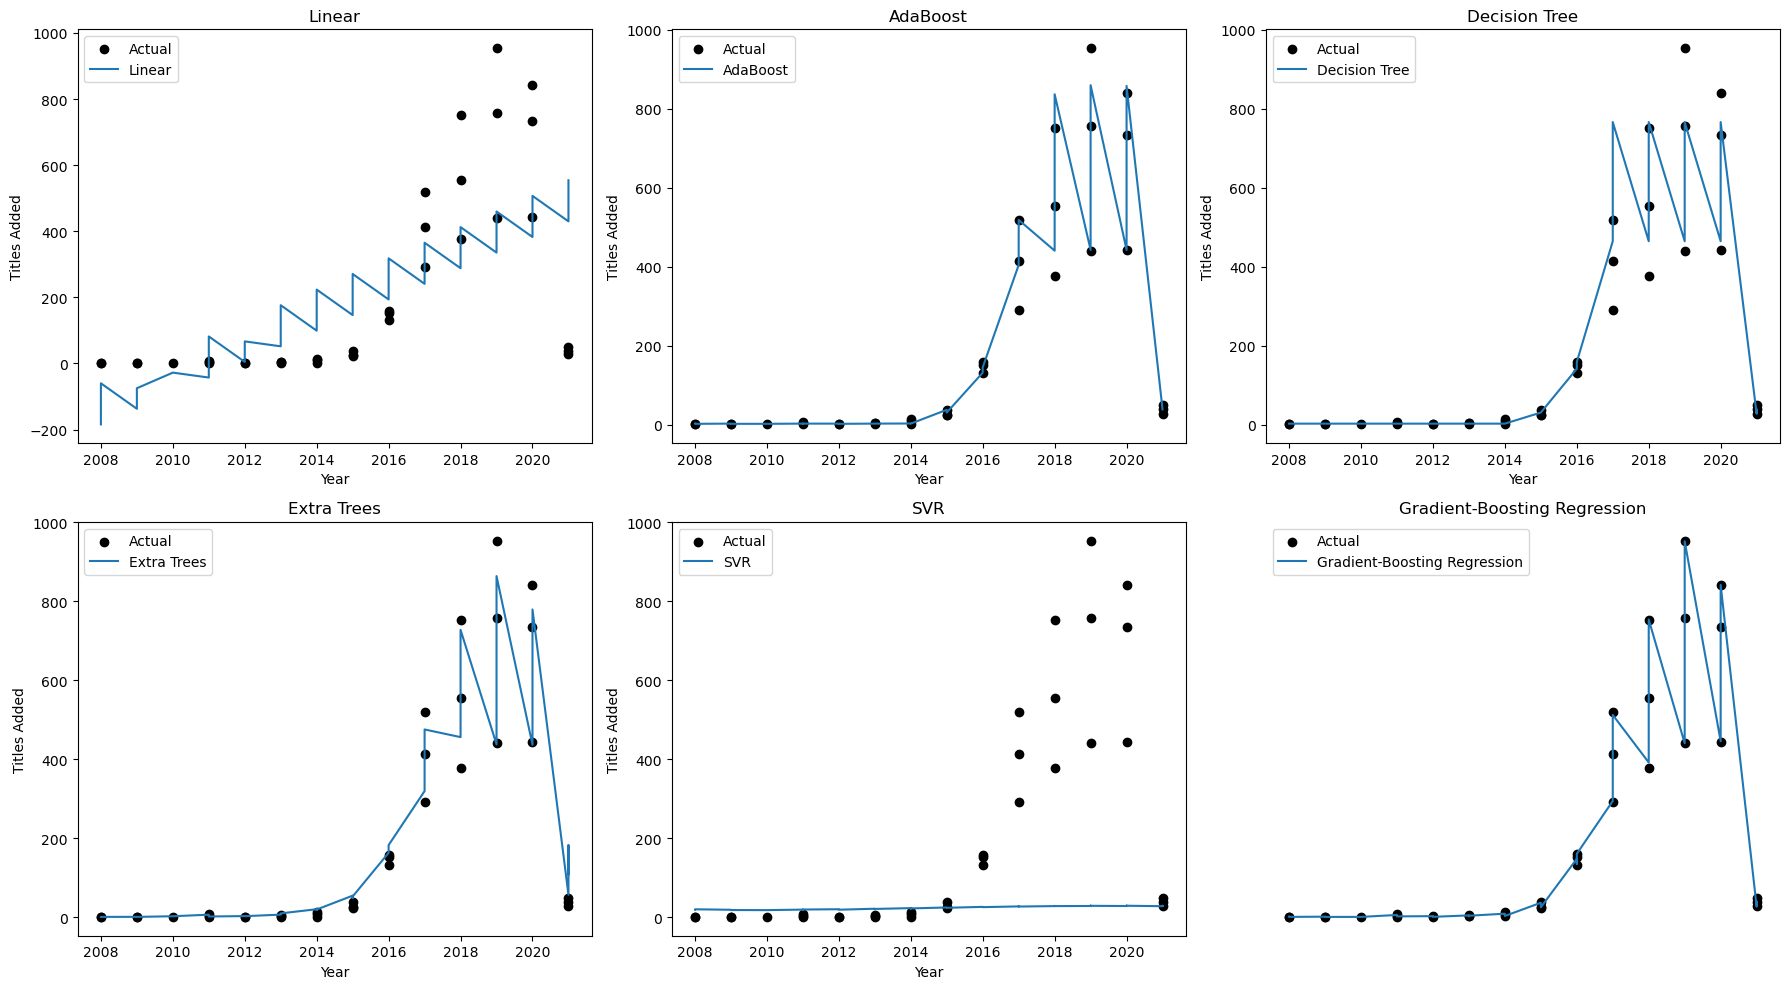

In [319]:
# Sort for smooth plotting
sorted_idx = X['year_added'].argsort()
X_sorted = X.iloc[sorted_idx]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # flatten to access easily

models = [
    ('Linear', linear_pipeline),
    ('AdaBoost', ada_pipeline),
    ('Decision Tree', tree_pipeline),
    ('Extra Trees', et_pipeline),
    ('SVR', svr_pipeline),
    ('Gradient-Boosting Regression',gb_pipeline)
]

for i, (name, model) in enumerate(models):
    ax = axes[i]
    
    # Scatter (actual)
    ax.scatter(X['year_added'], y, color='black', label='Actual')
    
    # Line (prediction)
    ax.plot(X_sorted['year_added'], model.predict(X_sorted), label=name)
    
    ax.set_title(name)
    ax.set_xlabel('Year')
    ax.set_ylabel('Titles Added')
    ax.legend()

# Hide the 6th empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

##  Conclusion: Forecasting Netflix Titles (2022–2025)

After comparing regression models, we see a wide divergence in forecasts:

- **Linear Regression** projects steady growth, from ~536 titles in 2022 to ~677 titles in 2025.  
- **AdaBoost, Decision Tree, Extra Trees, SVR, and Gradient Boosting** remain nearly flat, predicting between 25–39 titles per year, showing limited sensitivity to historical trends.  

###  Projected Titles Added (2022–2025)
Based on the table of model outputs:

| Year | Linear | AdaBoost | Decision Tree | Extra Trees | SVR | Gradient Boosting |
|------|--------|----------|---------------|-------------|-----|-------------------|
| 2022 | 536    | 39       | 28            | 177         | 28  | 39                |
| 2023 | 583    | 39       | 28            | 177         | 27  | 39                |
| 2024 | 630    | 39       | 28            | 177         | 26  | 39                |
| 2025 | 677    | 39       | 28            | 177         | 25  | 39                |

###  Key Takeaway
- **Linear Regression** suggests Netflix will continue adding **~140 more titles over 4 years**, reaching ~677 by 2025.  
- Other models (AdaBoost, SVR, Gradient Boosting) predict **minimal growth**, essentially flatlining around 25–40 titles annually.  
- **Extra Trees** sits in between, holding steady at ~177 titles per year.  

Overall, the **Linear Regression model provides the most realistic growth trajectory**, while the others appear underfit or overly constrained. If we trust the linear trend, Netflix’s catalog expansion will be moderate but consistent through 2025.

## Q7] How is Netflix content growing over time?

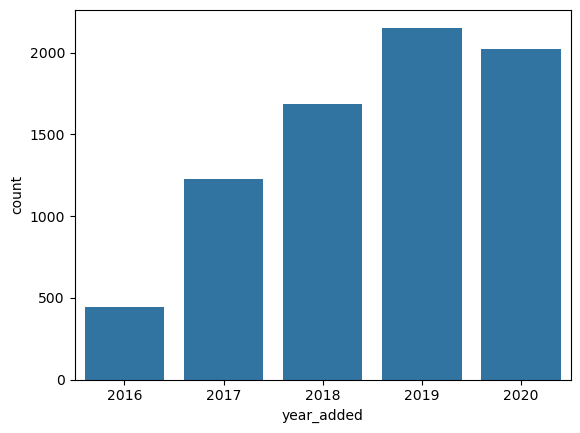

In [320]:
data = df["year_added"].value_counts().reset_index()
data = data.head(5)
sns.barplot(x=data["year_added"],y=data["count"])

plt.show()

In [321]:
yearly_data.sort_values(by="title_count",ascending=False).head(5)

,year_added,genre_count,title_count
30,2019,3,954
33,2020,3,841
29,2019,2,758
27,2018,3,753
32,2020,2,735


### CONCLUSION] Netflix content has shown a consistent upward trend over the years, with significant growth in recent years. Linear models were able to capture this trend effectively, while tree-based models failed due to their inability to extrapolate beyond training data. This highlights the importance of selecting models based on problem type rather than complexity.

## Q8] Who are the top contributing directors?

In [322]:
data = df["director"].value_counts().reset_index().head()
data = data[data["director"]!="Unknown"]
data

,director,count
1,"Raúl Campos, Jan Suter",18
2,Marcus Raboy,16
3,Jay Karas,14
4,Cathy Garcia-Molina,13


### CONCLUSION] The top contributing directors include:
1) Raúl Campos
2) Jan Suter
3) Marcus Raboy
4) Jay Karas
5) Cathy Garcia-Molina


## Q9] Which countries contribute most to the content-library?

In [323]:
data = df["first_country"].value_counts().reset_index().head()
data = data[data["first_country"]!="Unknown"]
data

,first_country,count
0,United States,2883
1,India,956
2,United Kingdom,577
4,Canada,259


### CONCLUSION] The top contributing countries are:
1) United States
2) India
3) United Kingdom
4) Canada

## Q10] Is there a statistically significant difference in the average duration of Netflix content between Movies and TV Shows?

In [324]:

from scipy.stats import ttest_ind


# Split data into two groups
movies = df[df['type'] == 'Movie']['duration_value']
tv_shows = df[df['type'] == 'TV Show']['duration_value']

# Perform Independent T-Test
t_stat, p_value = ttest_ind(movies, tv_shows, equal_var=False)

# Print results
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis (H0)")
    print("There is a statistically significant difference in duration.")
else:
    print("\nFail to Reject Null Hypothesis (H0)")
    print("No significant difference in duration.")

T-Statistic: 249.79900942857398
P-Value: 0.0

Reject Null Hypothesis (H0)
There is a statistically significant difference in duration.


### CONCLUSION] There is a significant difference in the durations of tv-shows and movies.

## Q11] Is the proportion of TV Shows significantly higher in recent years (after 2018) compared to older years?

In [325]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Create groups
recent = df[df['release_year'] >= 2018]
old = df[df['release_year'] < 2018]

# Count TV shows
success_recent = (recent['type'] == 'TV Show').sum()
success_old = (old['type'] == 'TV Show').sum()

# Total samples
n_recent = len(recent)
n_old = len(old)

# Z-test
count = np.array([success_recent, success_old])
nobs = np.array([n_recent, n_old])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("Z-stat:", z_stat)
print("P-value:", p_value)

# Decision
alpha = 0.05
if p_value < alpha:
    print("Reject H0: TV Shows proportion increased in recent years")
else:
    print("Fail to Reject H0")

Z-stat: 17.28945184862103
P-value: 2.8243427889897262e-67
Reject H0: TV Shows proportion increased in recent years


## Q12] Can Netflix content be grouped into meaningful clusters based on features like genre, cast size, and duration?

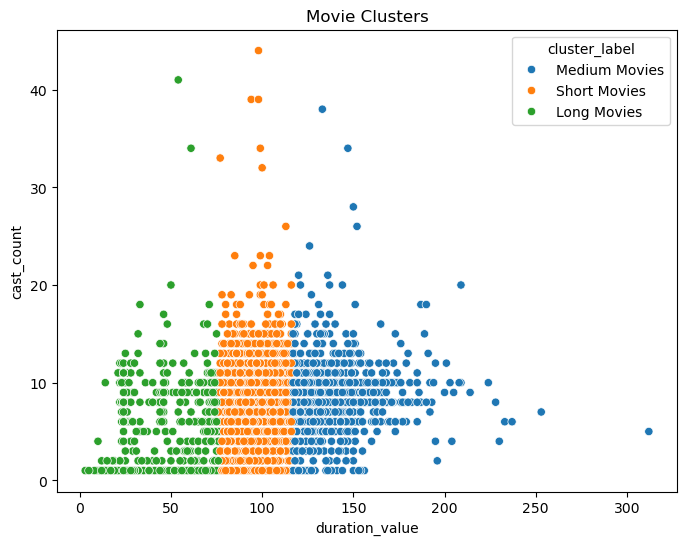

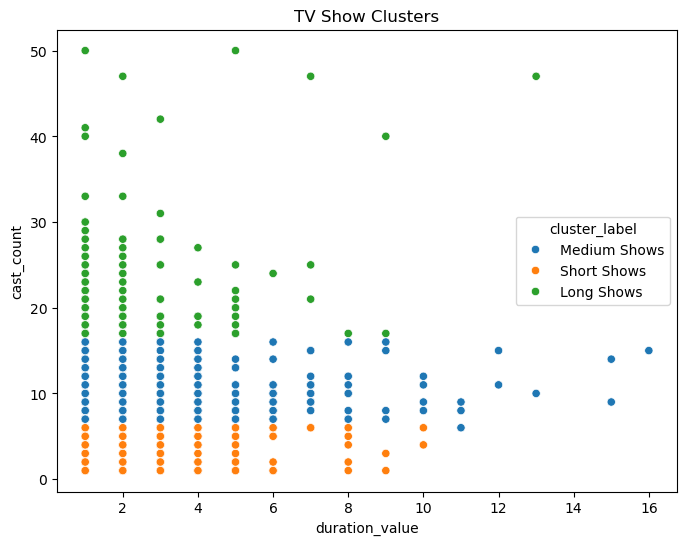

In [326]:
from sklearn.cluster import KMeans



movies_df = df[df['type'] == 'Movie'].copy()
tv_df = df[df['type'] == 'TV Show'].copy()


features = ['duration_value', 'cast_count', 'genre_count']






kmeans_movies = KMeans(n_clusters=3, random_state=42)
movies_df['cluster'] = kmeans_movies.fit_predict(movies_df[features])

movie_labels = {
    0: "Short Movies",
    1: "Medium Movies",
    2: "Long Movies"
}
movies_df['cluster_label'] = movies_df['cluster'].map(movie_labels)







kmeans_tv = KMeans(n_clusters=3, random_state=42)
tv_df['cluster'] = kmeans_tv.fit_predict(tv_df[features])

tv_labels = {
    0: "Short Shows",
    1: "Medium Shows",
    2: "Long Shows"
}
tv_df['cluster_label'] = tv_df['cluster'].map(tv_labels)









# Movies Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='duration_value',
    y='cast_count',
    hue='cluster_label',
    data=movies_df
)
plt.title("Movie Clusters")
plt.show()

# TV Shows Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='duration_value',
    y='cast_count',
    hue='cluster_label',
    data=tv_df
)
plt.title("TV Show Clusters")
plt.show()

In [327]:
print("\n--- MOVIE CLUSTERS ---")
for label in movies_df['cluster_label'].unique():
    subset = movies_df[movies_df['cluster_label'] == label]
    print(label)
    print("Avg Duration:", subset['duration_value'].mean())
    print("Avg Cast:", subset['cast_count'].mean())

print("\n--- TV SHOW CLUSTERS ---")
for label in tv_df['cluster_label'].unique():
    subset = tv_df[tv_df['cluster_label'] == label]
    print(label)
    print("Avg Duration:", subset['duration_value'].mean())
    print("Avg Cast:", subset['cast_count'].mean())


--- MOVIE CLUSTERS ---
Medium Movies
Avg Duration: 136.6070549630845
Avg Cast: 8.71862182116489
Short Movies
Avg Duration: 96.86318332829961
Avg Cast: 7.569918453639384
Long Movies
Avg Duration: 55.184179456906726
Avg Cast: 3.5962219598583234

--- TV SHOW CLUSTERS ---
Medium Shows
Avg Duration: 1.9271012006861064
Avg Cast: 10.01114922813036
Short Shows
Avg Duration: 1.5527502254283139
Avg Cast: 2.8872858431018935
Long Shows
Avg Duration: 2.303703703703704
Avg Cast: 22.666666666666668


## Q13] Which genres are **overcrowded** vs **underserved**?

In [328]:
from collections import Counter

new_df = df.copy()
new_df['genre_list'] = new_df['genres'].apply(lambda x: x.split(','))

all_genres = [g.strip() for sublist in new_df['genre_list'] for g in sublist]

genre_counts = Counter(all_genres)

genre_df = pd.DataFrame(genre_counts.items(), columns=['genre', 'count'])
genre_df = genre_df.sort_values(by='count', ascending=False)


In [329]:
print("Overcrowded genres:")
genre_df.head(10)

Overcrowded genres:


,genre,count
4,International Movies,2437
6,Dramas,2106
8,Comedies,1471
0,International TV Shows,1199
15,Documentaries,786
13,Action & Adventure,721
1,TV Dramas,704
12,Independent Movies,673
21,Children & Family Movies,532
14,Romantic Movies,531


In [330]:
print("Underserved genres:")
genre_df.tail(10)

Underserved genres:


,genre,count
38,TV Horror,69
36,Teen TV Shows,60
37,Cult Movies,59
23,Faith & Spirituality,57
41,Anime Features,57
26,Movies,56
35,Stand-Up Comedy & Talk Shows,52
33,TV Thrillers,50
40,Classic & Cult TV,27
20,TV Shows,12


## Q14] How has content production evolved over time?

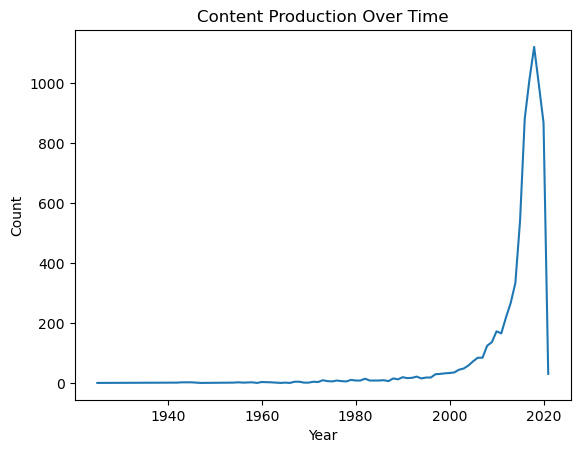

In [331]:
import matplotlib.pyplot as plt

df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

yearly = df.groupby('release_year').size()

yearly.plot(kind='line')
plt.title("Content Production Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

### CONCLUSION] With this we can say that most content-addition was done between the years 2000 and 2020.

In [332]:
df.head()

,type,title,director,cast,country,release_year,duration_value,genres,description,year_added,...,genre_count,duration_type,country_main,rating_category,has_director,first_country,country_encoded,tags,tokens,vector
0,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,...,3,TV Show,Brazil,Adult,0,Brazil,6,"3% international tv shows, tv dramas, tv sci-f...","[3, international, tv, shows, tv, dramas, tv, ...","[-0.2837069, 0.4586142, -0.2689379, 0.16273087..."
1,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2008,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017,...,3,Movie,India,Adult,1,India,28,"1920 horror movies, international movies, thri...","[1920, horror, movies, international, movies, ...","[-0.26550135, 0.5491217, -0.3310225, -0.042377..."
2,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2016,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019,...,3,Movie,Indonesia,Kids,1,Indonesia,29,"3 heroines dramas, international movies, sport...","[3, heroines, dramas, international, movies, s...","[-0.3266483, 0.5180785, -0.38953778, 0.0020336..."
3,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016,...,1,Movie,United States,Adult,1,United States,75,blue mountain state: the rise of thadland come...,"[blue, mountain, state, rise, thadland, comedi...","[-0.09417773, 0.43901843, -0.18432227, -0.1213..."
4,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2017,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018,...,3,TV Show,United Kingdom,Kids,0,United Kingdom,74,"blue planet ii british tv shows, docuseries, s...","[blue, planet, ii, british, tv, shows, docuser...","[-0.3298434, 0.6718903, -0.25556585, 0.2834716..."


## Q15] Now label sentiment for every content:

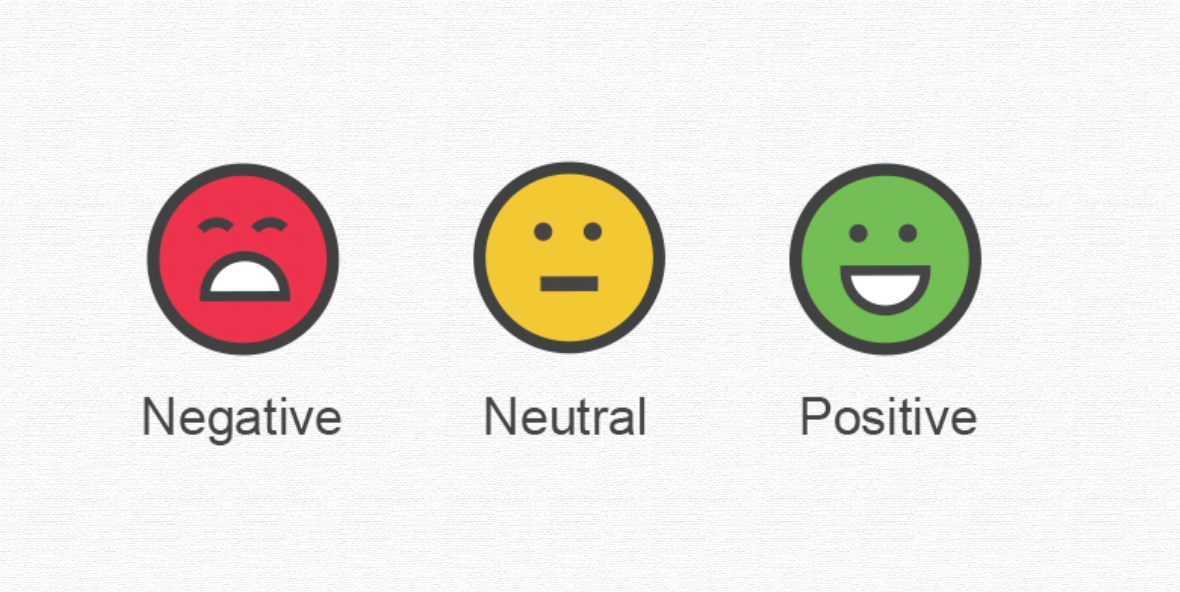

In [333]:
from IPython.display import Image, display
display(Image(filename="sentiments.png"))

In [334]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
analyzer = SentimentIntensityAnalyzer()

def preprocess_text(text):
    text = str(text).lower()
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]
    return " ".join(lemmatized_tokens)

def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['content_sentiment_text'] = df['description'].fillna('').apply(preprocess_text)
df['sentiment'] = df['content_sentiment_text'].apply(get_sentiment)

df[['title', 'description', 'content_sentiment_text', 'sentiment']].head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,title,description,content_sentiment_text,sentiment
0,3%,In a future where the elite inhabit an island ...,future elite inhabit island paradise far crowd...,Positive
1,1920,An architect and his wife move into a castle t...,architect wife move castle slated become luxur...,Positive
2,3 Heroines,Three Indonesian women break records by becomi...,three indonesian woman break record becoming f...,Positive
3,Blue Mountain State: The Rise of Thadland,New NFL star Thad buys his old teammates' belo...,new nfl star thad buy old teammate beloved fra...,Positive
4,Blue Planet II,This sequel to the award-winning nature series...,sequel nature series blue planet dive beneath ...,Positive


In [335]:
df.head(20)

,type,title,director,cast,country,release_year,duration_value,genres,description,year_added,...,country_main,rating_category,has_director,first_country,country_encoded,tags,tokens,vector,content_sentiment_text,sentiment
0,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,...,Brazil,Adult,0,Brazil,6,"3% international tv shows, tv dramas, tv sci-f...","[3, international, tv, shows, tv, dramas, tv, ...","[-0.2837069, 0.4586142, -0.2689379, 0.16273087...",future elite inhabit island paradise far crowd...,Positive
1,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2008,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017,...,India,Adult,1,India,28,"1920 horror movies, international movies, thri...","[1920, horror, movies, international, movies, ...","[-0.26550135, 0.5491217, -0.3310225, -0.042377...",architect wife move castle slated become luxur...,Positive
2,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2016,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019,...,Indonesia,Kids,1,Indonesia,29,"3 heroines dramas, international movies, sport...","[3, heroines, dramas, international, movies, s...","[-0.3266483, 0.5180785, -0.38953778, 0.0020336...",three indonesian woman break record becoming f...,Positive
3,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016,...,United States,Adult,1,United States,75,blue mountain state: the rise of thadland come...,"[blue, mountain, state, rise, thadland, comedi...","[-0.09417773, 0.43901843, -0.18432227, -0.1213...",new nfl star thad buy old teammate beloved fra...,Positive
4,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2017,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018,...,United Kingdom,Kids,0,United Kingdom,74,"blue planet ii british tv shows, docuseries, s...","[blue, planet, ii, british, tv, shows, docuser...","[-0.3298434, 0.6718903, -0.25556585, 0.2834716...",sequel nature series blue planet dive beneath ...,Positive
5,Movie,Blue Ruin,Jeremy Saulnier,"Macon Blair, Devin Ratray, Amy Hargreaves, Kev...","United States, France",2013,90,"Independent Movies, Thrillers",Bad news from the past unhinges vagabond Dwigh...,2019,...,United States,Adult,1,United States,75,"blue ruin independent movies, thrillers bad ne...","[blue, ruin, independent, movies, thrillers, b...","[-0.13902028, 0.519731, -0.23125061, -0.131514...",bad news past unhinges vagabond dwight evans s...,Negative
6,Movie,Blue Streak,Les Mayfield,"Martin Lawrence, Luke Wilson, Peter Greene, Da...","Germany, United States",1999,94,"Action & Adventure, Comedies",A jewel thief returns to his hiding place afte...,2021,...,Germany,Teen,1,Germany,21,"blue streak action & adventure, comedies a jew...","[blue, streak, action, adventure, comedies, je...","[-0.10283347, 0.42615846, -0.22298595, -0.0839...",jewel thief return hiding place stint jail fin...,Negative
7,Movie,Blue Valentine,Derek Cianfrance,"Ryan Gosling, Michelle Williams, Faith Wladyka...",United States,2010,112,"Dramas, Independent Movies, Romantic Movies",As Cindy and Dean muddle through their languis...,2018,...,United States,Adult,1,United States,75,"blue valentine dramas, independent movies, rom...","[blue, valentine, dramas, independent, movies,...","[-0.20689832, 0.6324842, -0.3143241, -0.136826...",cindy dean muddle languishing marriage hearken...,Positive
8,Movie,BluffMaster!,Rohan Sippy,"Abhishek Bachchan, Priyanka Chopra, Riteish De...",India,2005,129,"Comedies, International Movies, Romantic Movies",When his girlfri

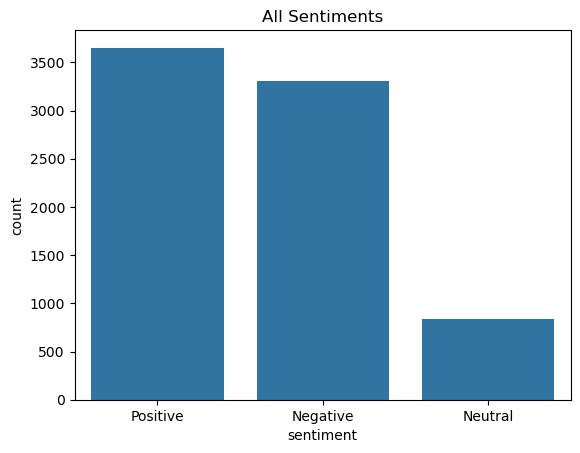

In [336]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.title("All Sentiments")
sns.countplot(x='sentiment', data=df, order=df['sentiment'].value_counts().index)

plt.show()

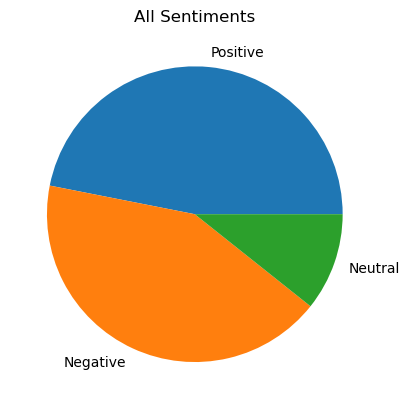

In [337]:
import matplotlib.pyplot as plt
plt.pie(df["sentiment"].value_counts(),labels=df["sentiment"].value_counts().index)
plt.title("All Sentiments")
plt.show()

### PROJECT BY:
- **Name:** Om Satyawan Pathak
- **Email:** omsatyawanpathakgit@gmail.com
- **Linkedin:** www.linkedin.com/in/om-satyawan-pathak-029b02368